## Lab4
In this lab you will create some simulated data and will fit simple
linear regression models to it. Make sure to use the default random
number generator with seed set to 1 prior to starting part (a) to
ensure consistent results.

In [9]:
# Import your libraries here
import numpy as np
import pandas as pd
import matplotlib as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence \
     import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
import seaborn as sns

np.random.seed(1)


**(a) Using the `normal()` method of your random number generator,
create a vector, X , containing 100 observations drawn from a
$N(0,1)$ distribution. This represents a feature, X.**

In [10]:
X = np.random.normal(0,1,100)
X

array([ 1.62434536, -0.61175641, -0.52817175, -1.07296862,  0.86540763,
       -2.3015387 ,  1.74481176, -0.7612069 ,  0.3190391 , -0.24937038,
        1.46210794, -2.06014071, -0.3224172 , -0.38405435,  1.13376944,
       -1.09989127, -0.17242821, -0.87785842,  0.04221375,  0.58281521,
       -1.10061918,  1.14472371,  0.90159072,  0.50249434,  0.90085595,
       -0.68372786, -0.12289023, -0.93576943, -0.26788808,  0.53035547,
       -0.69166075, -0.39675353, -0.6871727 , -0.84520564, -0.67124613,
       -0.0126646 , -1.11731035,  0.2344157 ,  1.65980218,  0.74204416,
       -0.19183555, -0.88762896, -0.74715829,  1.6924546 ,  0.05080775,
       -0.63699565,  0.19091548,  2.10025514,  0.12015895,  0.61720311,
        0.30017032, -0.35224985, -1.1425182 , -0.34934272, -0.20889423,
        0.58662319,  0.83898341,  0.93110208,  0.28558733,  0.88514116,
       -0.75439794,  1.25286816,  0.51292982, -0.29809284,  0.48851815,
       -0.07557171,  1.13162939,  1.51981682,  2.18557541, -1.39

**(b) Again using the `normal()` method, create a vector, `eps` , containing 100
observations drawn from a $N(0,0.25)$ distribution—a normal
distribution with mean zero and variance $0.25$.**

In [11]:
eps = np.random.normal(0,.5,100)
eps

array([-0.22356428,  0.61225385,  0.20174582,  0.29678926, -0.54745592,
        0.08469122,  0.37027823, -0.4768503 , -0.13310925,  0.01630727,
       -0.68655866,  0.1575797 ,  0.42308032, -0.42975797,  0.17527299,
       -0.65614171, -0.01934775, -0.80788618,  0.56070885,  0.20445027,
       -0.01230848, -0.38758081,  0.63687797,  0.98355087, -0.92899093,
        0.61808202,  0.81382538,  0.16900585, -0.59963402,  0.43167266,
       -0.09046015, -0.30196031, -0.61502907,  0.27526875,  0.39640343,
       -0.31176536,  0.26028817, -0.57217069,  0.40093052,  0.02328365,
       -0.09328489, -0.05087294,  0.43444308,  0.37520582,  0.26473266,
        0.0688506 ,  0.03891056,  0.30919013,  0.11624728,  0.3412757 ,
       -0.15505839, -1.21741888,  0.5194123 ,  1.09348982,  0.22068222,
       -0.05007762, -0.06822237, -0.05952709,  0.0087047 , -0.56100936,
       -0.25854723, -0.49851341,  0.12439958, -0.14832058,  0.24760566,
       -0.08735158,  0.49316759,  0.10676695,  1.09534986, -0.94

**(c) Using X and eps, generate a vector Y according to the model
\begin{equation}
Y = −1+0.5X + \epsilon.
\end{equation}
What is the length of the vector Y? What are the values of $\beta_0$
and $\beta_1$ in this linear model?**

In [12]:
Y = -1 + 0.5*X + eps
print(Y)
Y.shape
# values of beta_0 and beta_1

[-0.4113916  -0.69362435 -1.06234006 -1.23969505 -1.11475211 -2.06607813
  0.24268411 -1.85745375 -0.9735897  -1.10837791 -0.95550469 -1.87249066
 -0.73812828 -1.62178515 -0.25784229 -2.20608734 -1.10556186 -2.24681539
 -0.41818427 -0.50414212 -1.56261807 -0.81521895  0.08767333  0.23479804
 -1.47856296 -0.72378191 -0.24761974 -1.29887887 -1.73357806 -0.30314961
 -1.43629053 -1.50033708 -1.95861542 -1.14733407 -0.93921963 -1.31809766
 -1.29836701 -1.45496285  0.2308316  -0.60569427 -1.18920266 -1.49468742
 -0.93913607  0.22143312 -0.70986346 -1.24964722 -0.86563169  0.3593177
 -0.82367324 -0.35012274 -1.00497323 -2.39354381 -1.0518468  -0.08118154
 -0.88376489 -0.75676602 -0.64873067 -0.59397605 -0.84850163 -1.11843878
 -1.6357462  -0.87207934 -0.61913551 -1.29736699 -0.50813526 -1.12513744
  0.05898229 -0.13332464  1.18813757 -2.64642863 -2.04551525 -0.80148949
  0.34418139 -0.68623293 -0.82034803 -2.12425773 -0.48737345 -0.72966661
 -0.54491771 -0.77889521 -1.74744345 -0.94360517 -0.

(100,)

(Your answer here)

Vector Y has a length of 100.
$\beta_0$ = -1
$\beta_1$ = 0.5

**(d) Create a scatterplot displaying the relationship between X and
Y. Comment on what you observe.**

<Axes: >

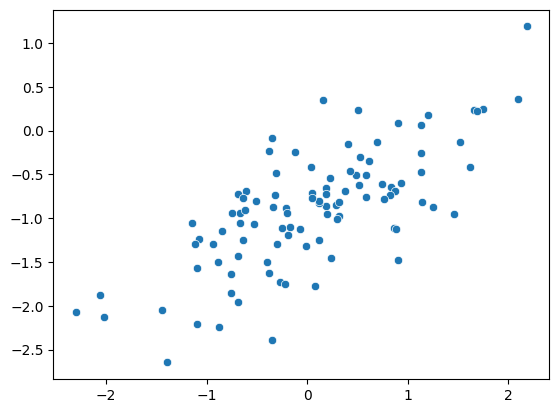

In [13]:
sns.scatterplot(x=X, y=Y)

(Your answer here)

It is a linear positive relationship

**(e) Fit a least squares linear model to predict Y using X . Comment
on the model obtained. How do $\hat{\beta}_0$ and $\hat{\beta}_1$ compare to $\beta_0$ and
$\beta_1$?**

In [20]:
model = sm.OLS(Y, sm.add_constant(X))
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
const,-0.9265,0.047,-19.717,0.0
x1,0.5477,0.053,10.342,0.0


(You answer here)

$\hat{\beta}_0$ = -0.9265 and
$\hat{\beta}_1$ = 0.5477,
these values are very similar to the actual values of
$\beta_0$ = -1 and
$\beta_1$ = 0.5.

**(f) Display the least squares line on the scatterplot obtained in (d).
Draw the population regression line on the plot, in a different
color. Use the `legend()` method of the axes to create an appropriate legend.**

In [22]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

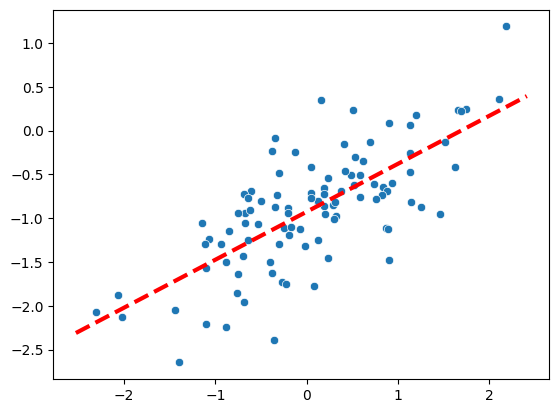

In [25]:
ax = sns.scatterplot(x=X, y=Y)
abline(ax, -0.9265, 0.5477, 'r--', linewidth=3)
plt.pyplot.show()

**(g) Now fit a polynomial regression model that predicts $Y$ using $X$
and $X^2$. Is there evidence that the quadratic term improves the
model fit? Explain your answer.**

In [27]:
model2 = sm.OLS(Y,sm.add_constant(X**2))
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
const,-0.9313,0.083,-11.250,0.000
x1,0.0483,0.061,0.795,0.429


(Your answer here)

**(h) Repeat (a)–(f) after modifying the data generation process in
such a way that there is ${\it less}$ noise in the data. The model (3.39)
should remain the same. You can do this by decreasing the variance of the normal distribution used to generate the error term
$\epsilon$ in (b). Describe your results.**

(You answer here)

**(i) Repeat (a)–(f) after modifying the data generation process in
such a way that there is ${\it more}$ noise in the data. The model (3.39)
should remain the same. You can do this by decreasing the variance of the normal distribution used to generate the error term
$\epsilon$ in (b). Describe your results.**

(Your answer here)

**(j) What are the confidence intervals for $\beta_0$ and $\beta_1$ based on the
original data set, the noisier data set, and the less noisy data
set? Comment on your results.**

(Your comment here)